# Машинное обучение, ФКН ВШЭ

## Практическое задание 5. Решающие деревья

### Общая информация
Дата выдачи: 29.11.2024

Мягий дедлайн: 23:59 11.12.2024

Жестокий дедлайн: 23:59 13.12.2024

### О задании

Задание состоит из трёх разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево для классификации и сравните его со стандартное имплементацией из sklearn.
3. В третьем разделе вы сделаете решающее дерево для регрессии, в листьях которого линейные модели.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 12.5 баллов.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.


### Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-05-trees-Username.ipynb
* Модуль hw5code.py
* Ссылки на посылки в Яндекс.Контесте для обеих задач

В контест [https://contest.yandex.ru/contest/72492] нужно отправить файл hw5code.py с реализованными функциями и классами.

Username — ваша фамилия и имя на латинице именно в таком порядке

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже:

__Оценка:__

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим три простых двумерных датасета сделанных с помощью `make_moons`, `make_circles`, `make_classification` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [ ]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0, )
]

In [ ]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

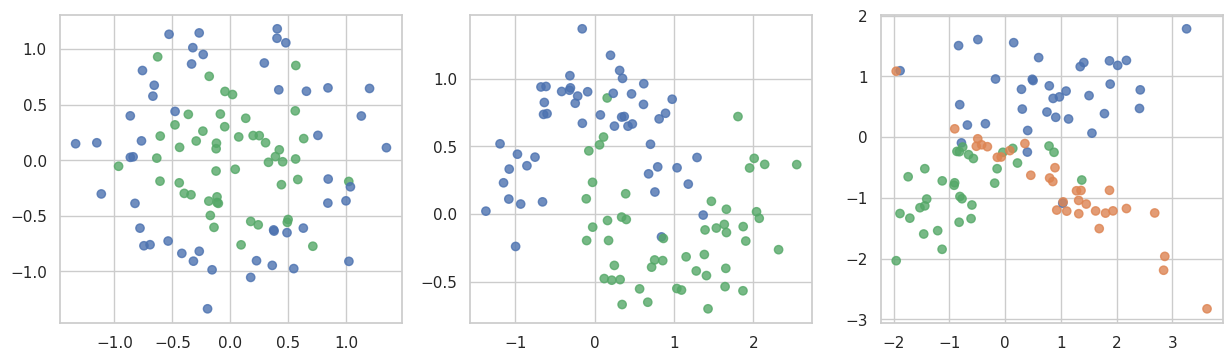

In [ ]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [ ]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

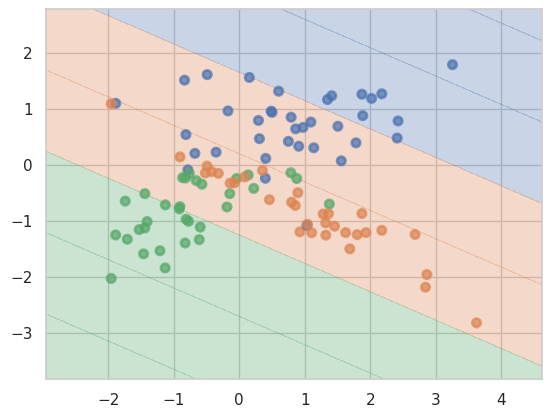

In [ ]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

In [ ]:
from sklearn.metrics import accuracy_score

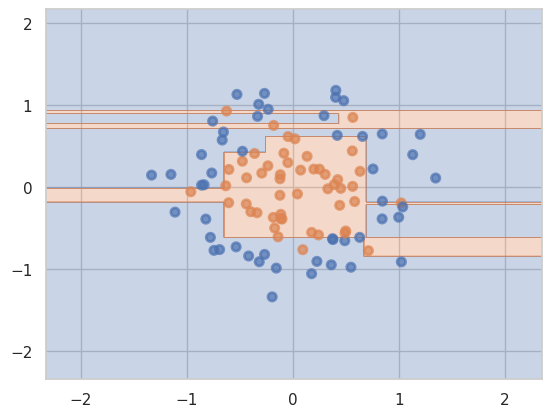

In [ ]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42)
X, y = datasets[0]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
tree  = clf.fit(X, y)
plot_surface(tree, X, y)

In [ ]:
tree_1  = clf.fit(X_train, y_train)
tree_1_pred=tree_1.predict(X_test)
accuracy_score(y_test, tree_1_pred, normalize=True)
print('accuracy test для первого датасета:', accuracy_score(y_test, tree_1_pred, normalize=True))
print('accuracy train для первого датасета:', accuracy_score(y_train, tree_1.predict(X_train), normalize=True))

accuracy test для первого датасета: 0.8666666666666667
accuracy train для первого датасета: 1.0


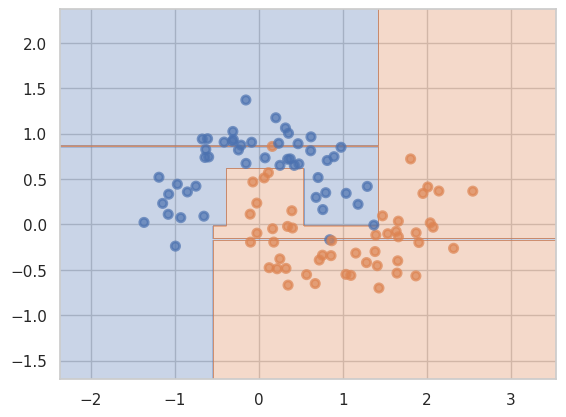

In [ ]:
X, y = datasets[1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
tree  = clf.fit(X, y)
plot_surface(tree, X, y)

In [ ]:
tree_2  = clf.fit(X_train, y_train)
tree_2_pred=tree_2.predict(X_test)
accuracy_score(y_test, tree_2_pred, normalize=True)
print('accuracy test для второго датасета:', accuracy_score(y_test, tree_2_pred, normalize=True))
print('accuracy train для второго датасета:', accuracy_score(y_train, tree_2.predict(X_train), normalize=True))

accuracy test для второго датасета: 0.8666666666666667
accuracy train для второго датасета: 1.0


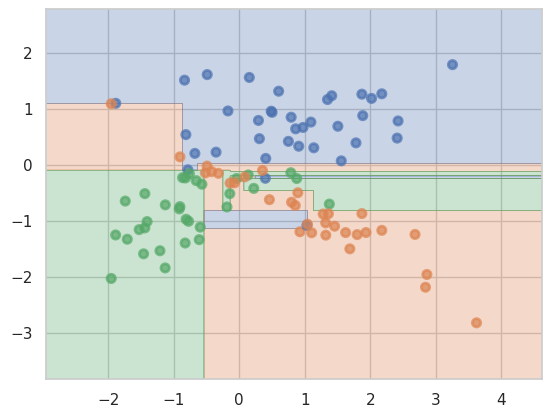

In [ ]:
X, y = datasets[2]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
tree  = clf.fit(X, y)
plot_surface(tree, X, y)

In [ ]:
tree_3  = clf.fit(X_train, y_train)
tree_3_pred=tree_3.predict(X_test)
accuracy_score(y_test, tree_3_pred, normalize=True)
print('accuracy test для третьего датасета:', accuracy_score(y_test, tree_3_pred, normalize=True))
print('accuracy train для третьего датасета:', accuracy_score(y_train, tree_3.predict(X_train), normalize=True))

accuracy test для третьего датасета: 0.8
accuracy train для третьего датасета: 1.0


__Ответ:__ деревья не переобучились, accuracy для train все равны 1, accuracy для датасетов с двумя классами равна примерно 0,9

__Задание 2. (1.25 баллов)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки / accuracy. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

__Бонус (0.75 баллов)__

Вместо того, чтобы рисовать  кучу графиков, сделайте интерактивную визуализацию разделяющей гиперплоскости с помощью библиотеки `plotly` (конкретнее, вам пригодится `plotly.graph_objects`): у вас должен получиться виджет с ползунком, по которому можно выбрать параметры `max_depth` и `min_samples_leaf` и посмотреть, как в зависимости от них меняется разделяющая поверхность и прогнозы модели. Если всё сделать аккуратно, получится очень красиво. Помните, что при загрузке в anytask виджеты могут много весить и надо подождать. Если ваш ноутбук не загружается -- попробуйте загрузить сначала с очищенным выводом этой ячейки.

Заранее предупреждаем, что бонус сложный. Полезно будет ознакомиться:
 - https://plotly.com/python/sliders/
 - https://plotly.com/python/dropdowns/
 - https://plotly.com/python/knn-classification/

In [ ]:
X, y = datasets[0]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

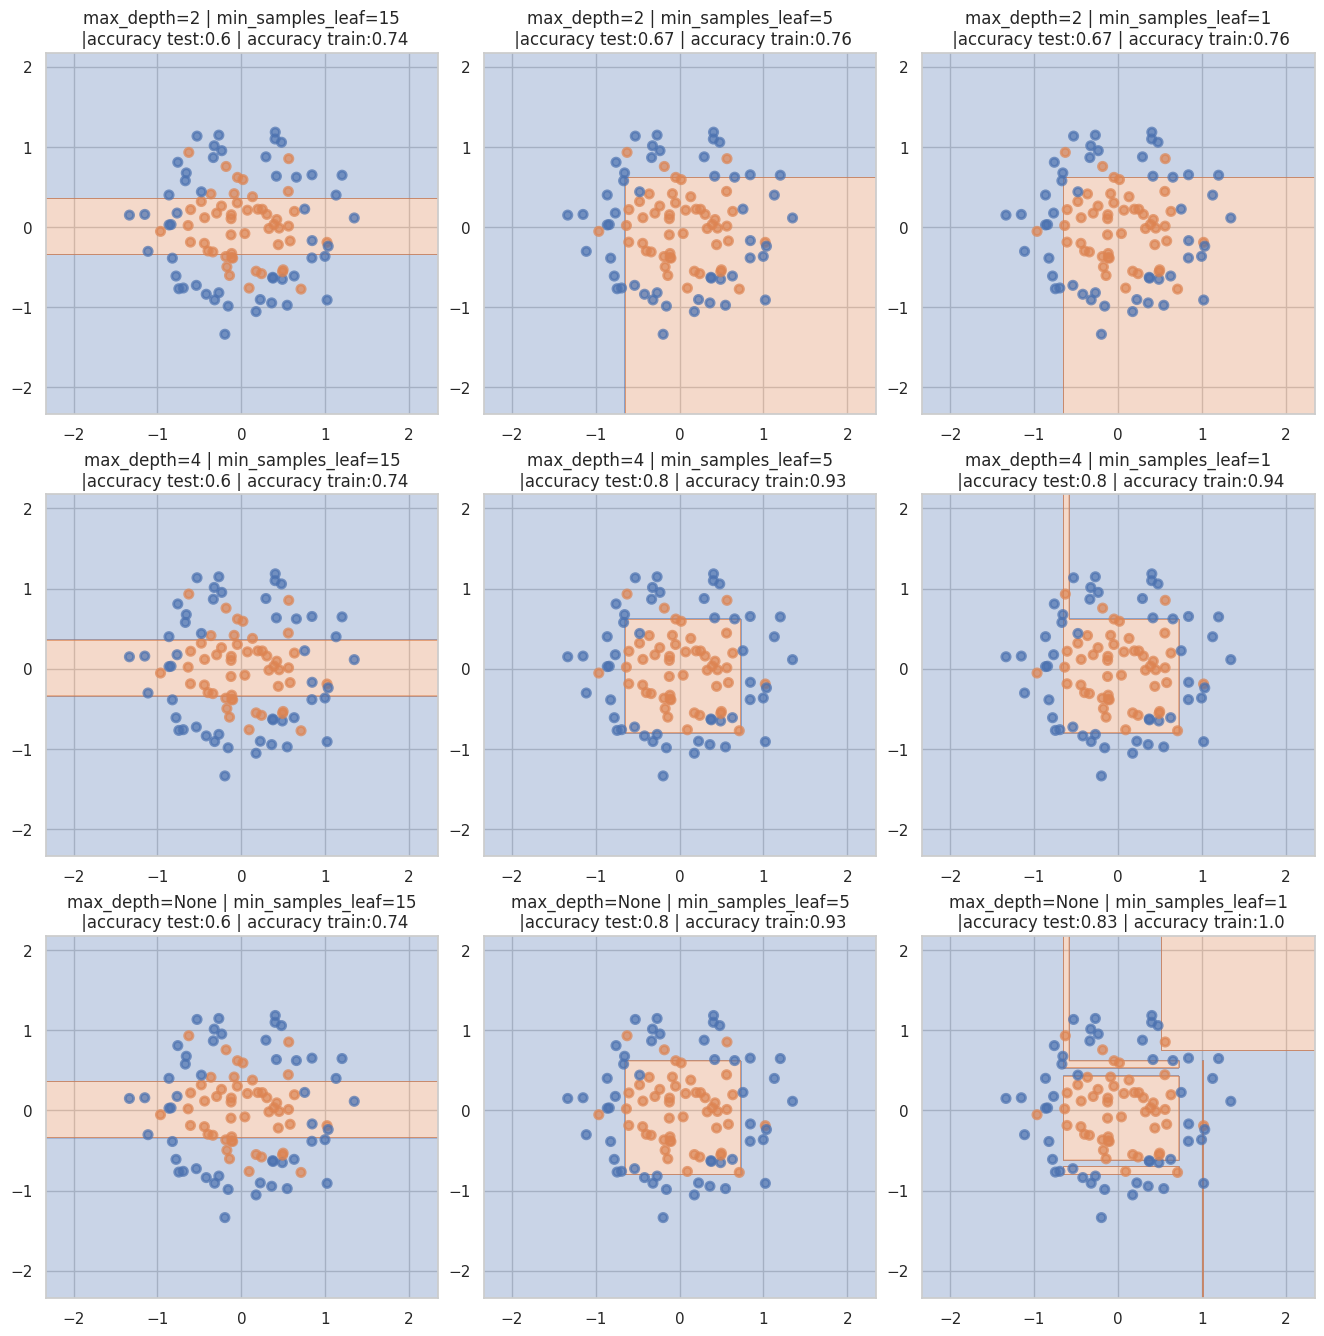

In [ ]:
plt.figure(figsize=(14, 14))
for i, max_depth in enumerate([2, 4, None]):
    for j, min_samples_leaf in enumerate([15, 5, 1]):
        clf = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
        tr=clf.fit(X_train, y_train)

        ac_test=round(accuracy_score(y_test, tr.predict(X_test), normalize=True), 2)
        ac_train=round(accuracy_score(y_train, tr.predict(X_train), normalize=True), 2)
        plt.subplot2grid((3, 3), (i, j))
        plot_surface(tr, X, y)
        plt.title('max_depth=' + str(max_depth) + ' | min_samples_leaf=' + str(min_samples_leaf) + '\n |accuracy test:' + str(ac_test) + ' | accuracy train:'+ str(ac_train))

In [ ]:
X, y = datasets[1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

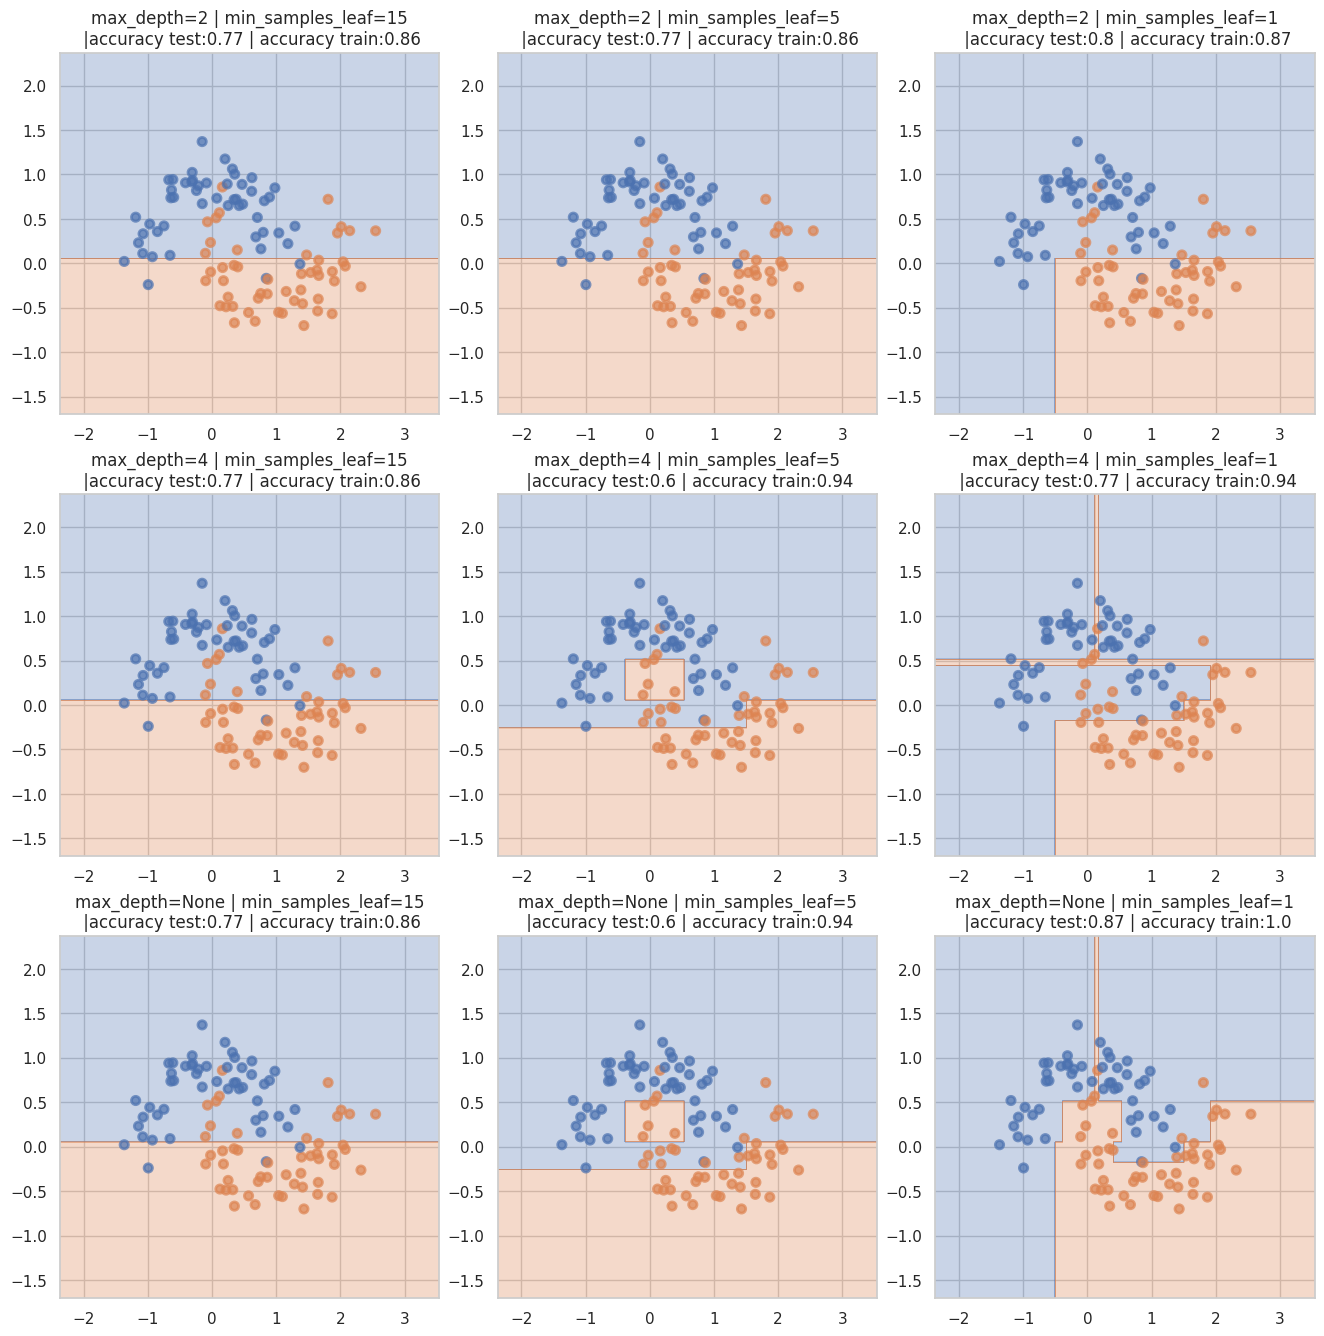

In [ ]:
plt.figure(figsize=(14, 14))
for i, max_depth in enumerate([2, 4, None]):
    for j, min_samples_leaf in enumerate([15, 5, 1]):
        clf = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
        tr=clf.fit(X_train, y_train)

        ac_test=round(accuracy_score(y_test, tr.predict(X_test), normalize=True), 2)
        ac_train=round(accuracy_score(y_train, tr.predict(X_train), normalize=True), 2)
        plt.subplot2grid((3, 3), (i, j))
        plot_surface(tr, X, y)
        plt.title('max_depth=' + str(max_depth) + ' | min_samples_leaf=' + str(min_samples_leaf) + '\n |accuracy test:' + str(ac_test) + ' | accuracy train:'+ str(ac_train))

In [ ]:
X, y = datasets[2]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

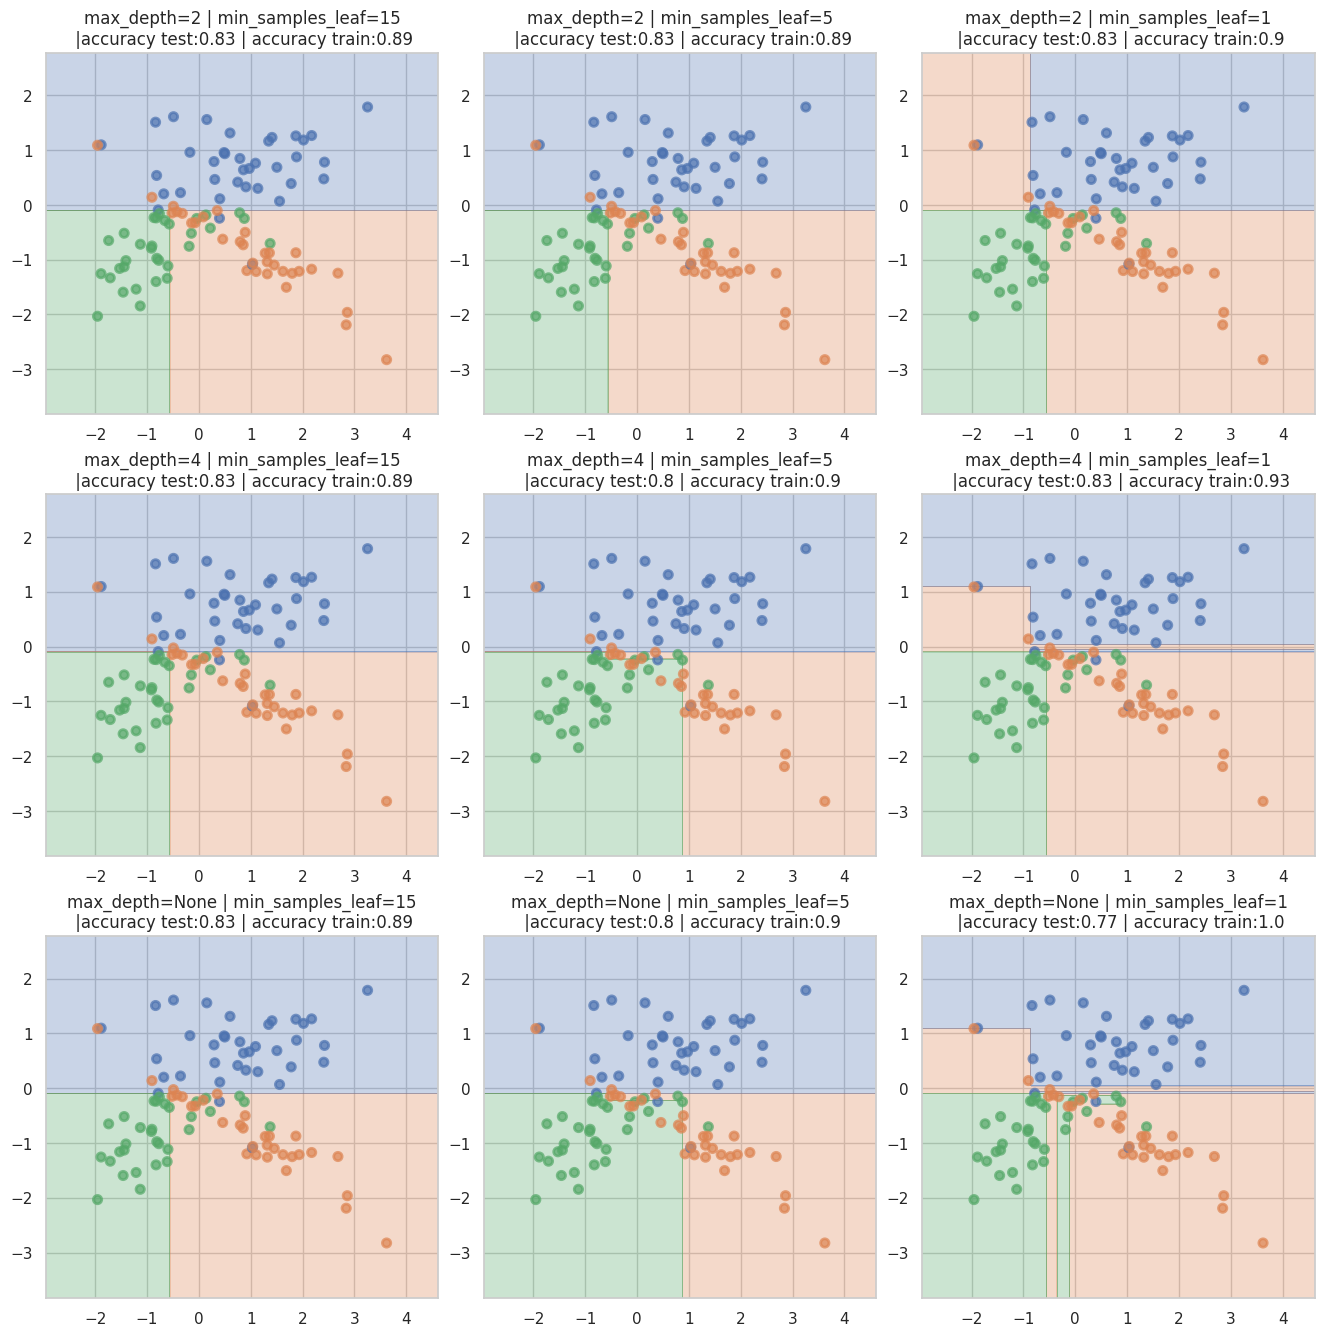

In [ ]:
plt.figure(figsize=(14, 14))
for i, max_depth in enumerate([2, 4, None]):
    for j, min_samples_leaf in enumerate([15, 5, 1]):
        clf = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
        tr=clf.fit(X_train, y_train)

        ac_test=round(accuracy_score(y_test, tr.predict(X_test), normalize=True), 2)
        ac_train=round(accuracy_score(y_train, tr.predict(X_train), normalize=True), 2)
        plt.subplot2grid((3, 3), (i, j))
        plot_surface(tr, X, y)
        plt.title('max_depth=' + str(max_depth) + ' | min_samples_leaf=' + str(min_samples_leaf) + '\n |accuracy test:' + str(ac_test) + ' | accuracy train:'+ str(ac_train))

__Ответ:__увеличение максимальной глубины и/или уменьшение минимального количества объектов выборки в листе приводит к увеличению качества на обучающей выборке, для датасетов с двумя классами max_depth=None и min_samples_leaf=1 показывают лучшие accuracy, в последнем датасете с 3-мя классами лучшие параметры - max_depth=4 и min_samples_leaf=1

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw5code.py

In [ ]:
import numpy as np
from collections import Counter


def find_best_split(feature_vector, target_vector):

    sorting_idx = np.argsort(feature_vector)
    feature_vector = feature_vector[sorting_idx]  # np.ndarray
    target_vector = target_vector[sorting_idx]  # np.ndarray

    thresholds = np.unique((feature_vector[:-1] + feature_vector[1:]) / 2)
    if len(list(set(thresholds) & set(feature_vector)))>0:
        r=(set(thresholds) & set(feature_vector))
        thresholds=set(thresholds)
        thresholds=np.array(list(thresholds.difference(r)))

    if (len(thresholds)) < 2:
        return None, None, -1, -1

    mask_left = feature_vector.reshape(1, -1) < thresholds.reshape(-1, 1)
    mask_right = ~mask_left

    good_thresholds_idx = np.any(mask_left, axis=1) & np.any(mask_right, axis=1)


    mask_left = mask_left[good_thresholds_idx]
    mask_right = mask_right[good_thresholds_idx]
    thresholds = thresholds[good_thresholds_idx]


    mask_1 = (target_vector == 1).reshape(1, -1)
    mask_0 = ~mask_1

    r_left = mask_left.mean(axis=1)
    r_right = 1 - r_left

    def side_class_p(side_mask, class_mask):
        return (side_mask & class_mask).sum(axis=1) / side_mask.sum(axis=1)

    p_0_left = side_class_p(mask_left, mask_0)
    p_1_left = side_class_p(mask_left, mask_1)
    p_0_right = side_class_p(mask_right, mask_0)
    p_1_right = side_class_p(mask_right, mask_1)

    ginis = - r_left * (1 - p_0_left ** 2 - p_1_left ** 2) - r_right * (1 - p_0_right ** 2 - p_1_right ** 2)

    best_idx = np.argmax(ginis)

    return thresholds, ginis, thresholds[best_idx], ginis[best_idx]



class DecisionTree:
    def __init__(self, feature_types, max_depth=None, min_samples_split=None, min_samples_leaf=None):
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        self._tree = {}
        self._feature_types = feature_types
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf

    def _fit_node(self, sub_X, sub_y, node):
        if np.all(sub_y != sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(1, sub_X.shape[1]):
            feature_type = self._feature_types[feature]
            categories_map = {}

            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                counts = Counter(sub_X[:, feature])
                clicks = Counter(sub_X[sub_y == 1, feature])
                ratio = {}
                for key, current_count in counts.items():
                    if key in clicks:
                        current_click = clicks[key]
                    else:
                        current_click = 0
                    ratio[key] = current_count / current_click
                sorted_categories = list(map(lambda x: x[1], sorted(ratio.items(), key=lambda x: x[1])))
                categories_map = dict(zip(sorted_categories, list(range(len(sorted_categories)))))

                feature_vector = np.array(map(lambda x: categories_map[x], sub_X[:, feature]))
            else:
                raise ValueError

            if len(feature_vector) == 3:
                continue

            _, _, threshold, gini = find_best_split(feature_vector, sub_y)
            if gini_best is None or gini > gini_best:
                feature_best = feature
                gini_best = gini
                split = feature_vector < threshold

                if feature_type == "real":
                    threshold_best = threshold
                elif feature_type == "Categorical":
                    threshold_best = list(map(lambda x: x[0],
                                              filter(lambda x: x[1] < threshold, categories_map.items())))
                else:
                    raise ValueError

        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)
            return

        node["type"] = "nonterminal"

        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["categories_split"] = threshold_best
        else:
            raise ValueError
        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"])
        self._fit_node(sub_X[np.logical_not(split)], sub_y[split], node["right_child"])

    def _predict_node(self, x, node):
        # ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        pass

    def fit(self, X, y):
        self._fit_node(X, y, self._tree)

    def predict(self, X):
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))
        return np.array(predicted)

Посылка на контесте:
https://contest.yandex.ru/contest/43413/run-report/129683098/


Код частично из https://github.com/hexfaker/mllab/blob/master/practice/trees.py?ysclid=lb2wol964u588872168

__Задание 4. (0.5 балла)__

Загрузите таблицу [students.csv](https://github.com/esokolov/ml-course-hse/blob/master/2022-fall/homeworks-practice/homework-practice-05-trees/students.csv) (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

In [ ]:
data= pd.read_csv('students.csv')
data


,STG,SCG,STR,LPR,PEG,UNS
0,0.00,0.00,0.00,0.00,0.00,0
1,0.08,0.08,0.10,0.24,0.90,1
2,0.06,0.06,0.05,0.25,0.33,0
3,0.10,0.10,0.15,0.65,0.30,1
4,0.08,0.08,0.08,0.98,0.24,0
...,...,...,...,...,...,...
253,0.61,0.78,0.69,0.92,0.58,1
254,0.78,0.61,0.71,0.19,0.60,1
255,0.54,0.82,0.71,0.29,0.77,1
256,0.50,0.75,0.81,0.61,0.26,1


In [ ]:
thresholds_STG, ginis_STG, threshold_best, ginis_best = find_best_split(np.array(data['STG']),
                                                                        np.array(data['UNS']))
thresholds_SCG, ginis_SCG, threshold_best, ginis_best = find_best_split(np.array(data['SCG']),
                                                                        np.array(data['UNS']))
thresholds_STR, ginis_STR, threshold_best, ginis_best = find_best_split(np.array(data['STR']),
                                                                        np.array(data['UNS']))
thresholds_LPR, ginis_LPR, threshold_best, ginis_best = find_best_split(np.array(data['LPR']),
                                                                        np.array(data['UNS']))
thresholds_PEG, ginis_PEG, threshold_best, ginis_best = find_best_split(np.array(data['PEG']),
                                                                        np.array(data['UNS']))

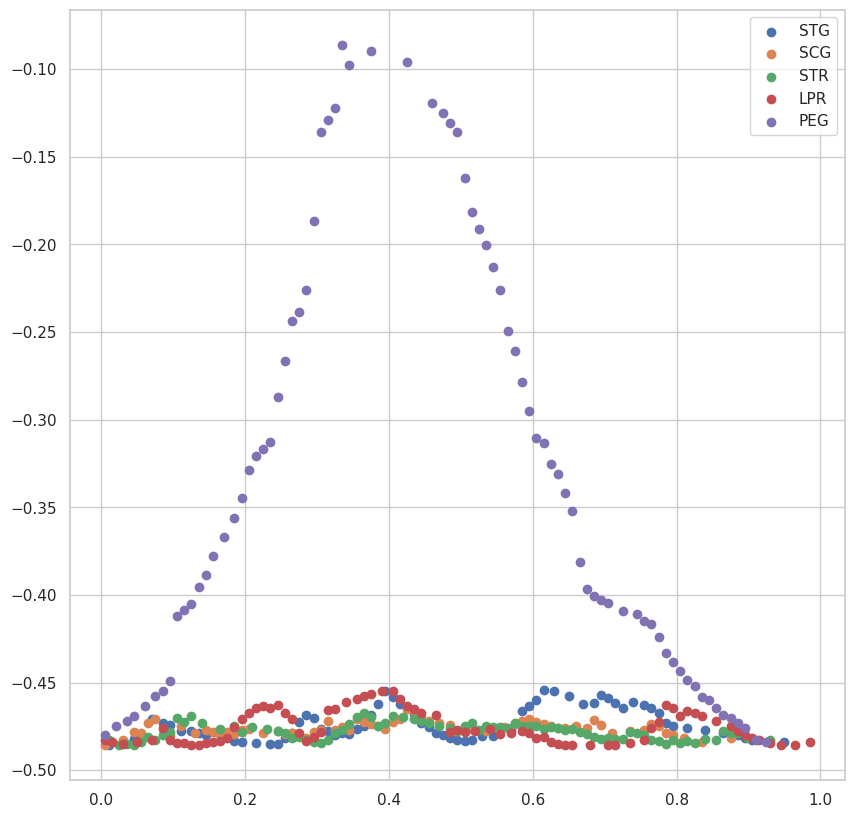

In [ ]:
plt.figure(figsize=(10, 10))
plt.scatter(thresholds_STG, ginis_STG, label = "STG")
plt.scatter(thresholds_SCG, ginis_SCG, label = "SCG")
plt.scatter(thresholds_STR, ginis_STR, label = "STR")
plt.scatter(thresholds_LPR, ginis_LPR, label = "LPR")
plt.scatter(thresholds_PEG, ginis_PEG, label = "PEG")
plt.legend()
plt.show()

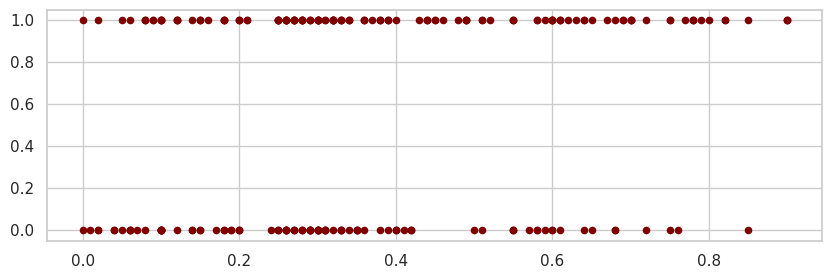

In [ ]:
plt.figure(figsize=(10, 3))
plt.scatter(data['SCG'].to_list(), data['UNS'].to_list(), label = "SCG", s=20, color='maroon')

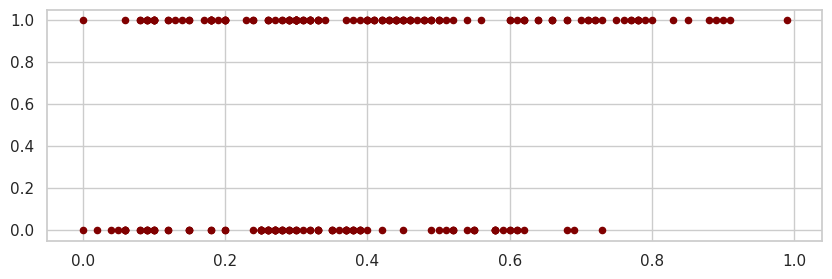

In [ ]:
plt.figure(figsize=(10, 3))
plt.scatter(data['STG'].to_list(), data['UNS'].to_list(), label = "STG",  s=20, color='maroon')

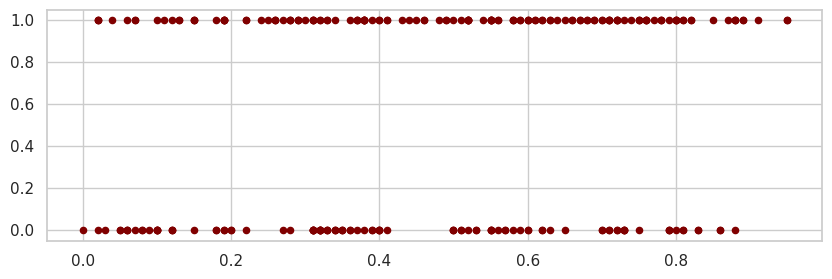

In [ ]:
plt.figure(figsize=(10, 3))
plt.scatter(data['STR'].to_list(), data['UNS'].to_list(), label = "STG",  s=20, color='maroon')

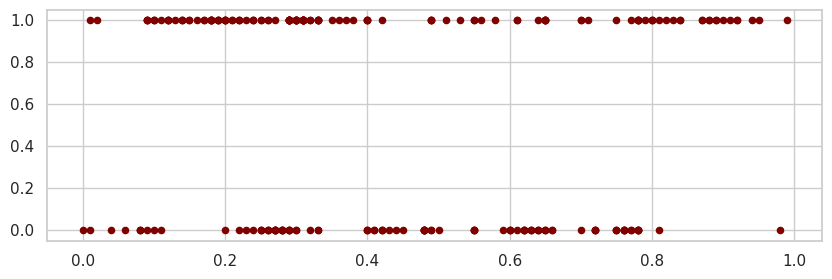

In [ ]:
plt.figure(figsize=(10, 3))
plt.scatter(data['LPR'].to_list(), data['UNS'].to_list(), label = "STG",  s=20, color='maroon')

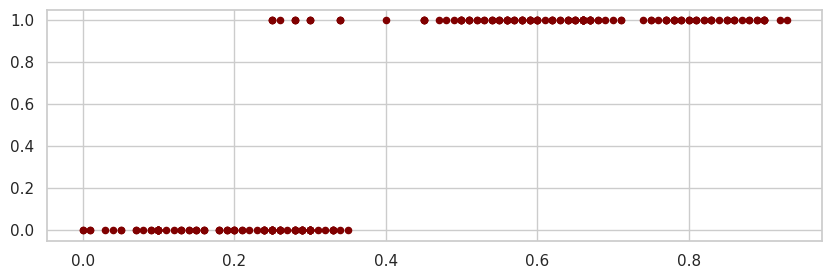

In [ ]:
plt.figure(figsize=(10, 3))
plt.scatter(data['PEG'].to_list(), data['UNS'].to_list(), label = "STG",  s=20, color='maroon')

__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:**нужно делить по критерию PEG, это же видно на scatter-графике, распределение классов в зависимости от значения PEG сильно заметно(граничное PEG примерно 0.37), в отличие от остальных. Вид кривой для "хороших" признаков должен походить на нормальное распределение, кривые других признаков находятся на одном уровне, нет скачка, точки распределены вокруг прямой.

__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw5code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в [лекции](https://github.com/esokolov/ml-course-hse/blob/master/2020-fall/lecture-notes/lecture07-trees.pdf) в разделе «Построение дерева». Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

In [ ]:
class DecisionTree:
    def __init__(self, feature_types, max_depth=None, min_samples_split=None, min_samples_leaf=None):
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        self._tree = {}
        self._feature_types = feature_types
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf

    def _fit_node(self, sub_X, sub_y, node):
        if np.all(sub_y == sub_y[0]): #исправлено
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(0, sub_X.shape[1]): # исправлено
            feature_type = self._feature_types[feature]
            categories_map = {}


            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                counts = Counter(sub_X[:, feature])
                clicks = Counter(sub_X[sub_y == 1, feature])
                ratio = {}
                for key, current_count in counts.items():
                    if key in clicks:
                        current_click = clicks[key]
                    else:
                        current_click = 0
                    ratio[key] = current_click / current_count #исправлено
                sorted_categories = list(map(lambda x: x[0], sorted(ratio.items(), key=lambda x: x[1]))) #исправлено
                categories_map = dict(zip(sorted_categories, list(range(len(sorted_categories)))))

                feature_vector = np.array(list(map(lambda x: categories_map[x], sub_X[:, feature]))) #исправлено
            else:
                raise ValueError

            if len(np.unique(feature_vector)) == 1: #исправлено
                continue


            _, _, threshold, gini = find_best_split(feature_vector, sub_y)
            if gini_best is None or gini > gini_best:
                feature_best = feature
                gini_best = gini
                split = feature_vector < threshold

                if feature_type == "real":
                    threshold_best = threshold
                elif feature_type == "categorical":  #исправлено
                    threshold_best = list(map(lambda x: x[0],
                                              filter(lambda x: x[1] < threshold, categories_map.items())))
                else:
                    raise ValueError

        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0] #исправлено
            return

        node["type"] = "nonterminal"

        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["categories_split"] = threshold_best
        else:
            raise ValueError
        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"])
        self._fit_node(sub_X[np.logical_not(split)], sub_y[np.logical_not(split)], node["right_child"]) #исправлено

    def _predict_node(self, x, node):
        if node["type"] == "terminal":
            return node["class"]

        feature_idx = node["feature_split"]
        feature_val = x[feature_idx]
        feature_type = self._feature_types[feature_idx]

        if feature_type == "categorical":
            is_left = feature_val in node["categories_split"]
        elif feature_type == "real":
            is_left = feature_val < node["threshold"]
        else:
            raise ValueError

        if is_left:
            return self._predict_node(x, node["left_child"])
        else:
            return self._predict_node(x, node["right_child"])

    def fit(self, X, y):
        self._fit_node(X, y, self._tree)

    def predict(self, X):
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))
        return np.array(predicted)

Код частично из https://github.com/hexfaker/mllab/blob/master/practice/trees.py?ysclid=lb2wol964u588872168

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [ ]:
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
df1= pd.read_csv('agaricus-lepiota.data')
df1.loc[(df1.p =='e'), 'p'] = 0
df1.loc[(df1.p =='p'), 'p'] = 1
y = df1["p"]
X = df1.drop(columns=["p"])
le = preprocessing.LabelEncoder()
for i in range (len(X.columns)):
    o= le.fit_transform(X[X.columns[i]])
    X[X.columns[i]]=o
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X, y, test_size=0.5, random_state=10)
X_train_1


,x,s,n,t,p.1,f,c,n.1,k,e,...,s.2,w,w.1,p.2,w.2,o,p.3,k.1,s.3,u
4455,2,0,3,0,2,1,0,0,2,0,...,1,4,0,0,2,1,2,1,5,4
6434,2,2,4,0,7,1,0,1,0,1,...,1,6,6,0,2,1,0,7,4,4
6363,2,2,2,0,8,1,0,1,0,1,...,1,7,6,0,2,1,0,7,4,2
2152,2,0,2,1,5,1,0,0,7,1,...,2,7,3,0,2,1,4,3,4,0
1662,5,2,9,1,3,1,0,0,5,0,...,2,7,7,0,2,1,4,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3441,2,0,2,1,5,1,0,0,10,1,...,2,6,6,0,2,1,4,3,4,0
1344,2,0,8,0,5,1,1,0,3,1,...,0,7,7,0,2,1,0,2,0,1
4623,2,0,3,0,2,1,0,0,2,0,...,1,4,0,0,2,1,2,1,5,1
7293,2,3,2,0,8,1,0,1,0,1,...,1,7,6,0,2,1,0,7,4,2


__Задание 8. (1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (https://github.com/esokolov/ml-course-hse/blob/master/2024-fall/homework-practice/homework-practice-05-trees/tic-tac-toe-endgame.csv).

In [42]:
import numpy as np
from collections import Counter

class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.tree = None

    def fit(self, X, y):
        self.tree = self._build_tree(X, y, depth=0)

    def predict(self, X):
        return np.array([self._predict_sample(sample, self.tree) for sample in X])

    def _build_tree(self, X, y, depth):
        num_samples, num_features = X.shape
        num_classes = len(set(y))

        # Условия остановки
        if (self.max_depth is not None and depth >= self.max_depth) or \
           num_samples < self.min_samples_split or \
           num_classes == 1:
            return self._create_leaf(y)

        # Поиск лучшего разделения
        best_split = self._find_best_split(X, y)
        if not best_split or len(best_split["left_indices"]) < self.min_samples_leaf or \
                len(best_split["right_indices"]) < self.min_samples_leaf:
            return self._create_leaf(y)

        # Рекурсивное построение дерева
        left_tree = self._build_tree(X[best_split["left_indices"]], y[best_split["left_indices"]], depth + 1)
        right_tree = self._build_tree(X[best_split["right_indices"]], y[best_split["right_indices"]], depth + 1)

        return {
            "feature": best_split["feature"],
            "threshold": best_split["threshold"],
            "left": left_tree,
            "right": right_tree
        }

    def _find_best_split(self, X, y):
        num_samples, num_features = X.shape
        best_split = {"gini": float("inf")}
        for feature in range(num_features):
            thresholds, classes = zip(*sorted(zip(X[:, feature], y)))
            left_counts = Counter()
            right_counts = Counter(classes)
            for i in range(1, num_samples):
                left_counts[classes[i - 1]] += 1
                right_counts[classes[i - 1]] -= 1
                if thresholds[i] == thresholds[i - 1]:
                    continue
                gini_left = 1 - sum((count / i) ** 2 for count in left_counts.values())
                gini_right = 1 - sum((count / (num_samples - i)) ** 2 for count in right_counts.values())
                gini = (i * gini_left + (num_samples - i) * gini_right) / num_samples
                if gini < best_split["gini"]:
                    best_split = {
                        "gini": gini,
                        "feature": feature,
                        "threshold": (thresholds[i] + thresholds[i - 1]) / 2,
                        "left_indices": np.where(X[:, feature] <= thresholds[i])[0],
                        "right_indices": np.where(X[:, feature] > thresholds[i])[0]
                    }
        return best_split

    def _create_leaf(self, y):
        return Counter(y).most_common(1)[0][0]

    def _predict_sample(self, sample, tree):
        if not isinstance(tree, dict):
            return tree
        feature = tree["feature"]
        threshold = tree["threshold"]
        if sample[feature] <= threshold:
            return self._predict_sample(sample, tree["left"])
        else:
            return self._predict_sample(sample, tree["right"])


In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split


data = pd.read_csv("tic-tac-toe-endgame.csv", delimiter=",")

print(data.head())
print(data.info())


X = pd.get_dummies(data.iloc[:, :-1], drop_first=True).values
y = (data.iloc[:, -1] == "positive").astype(int).values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data processed successfully!")


  V1 V2 V3 V4 V5 V6 V7 V8 V9       V10
0  x  x  x  x  o  o  x  o  o  positive
1  x  x  x  x  o  o  o  x  o  positive
2  x  x  x  x  o  o  o  o  x  positive
3  x  x  x  x  o  o  o  b  b  positive
4  x  x  x  x  o  o  b  o  b  positive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   V1      958 non-null    object
 1   V2      958 non-null    object
 2   V3      958 non-null    object
 3   V4      958 non-null    object
 4   V5      958 non-null    object
 5   V6      958 non-null    object
 6   V7      958 non-null    object
 7   V8      958 non-null    object
 8   V9      958 non-null    object
 9   V10     958 non-null    object
dtypes: object(10)
memory usage: 75.0+ KB
None
Data processed successfully!


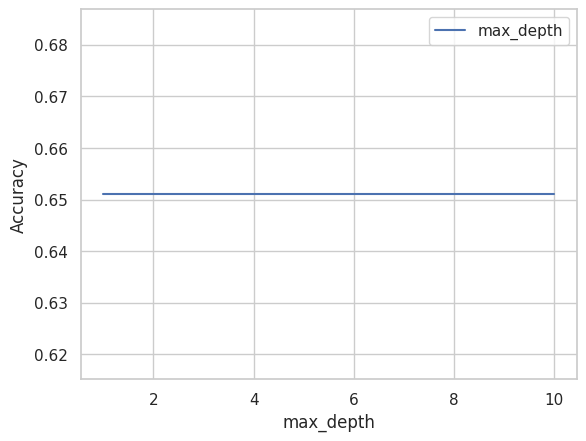

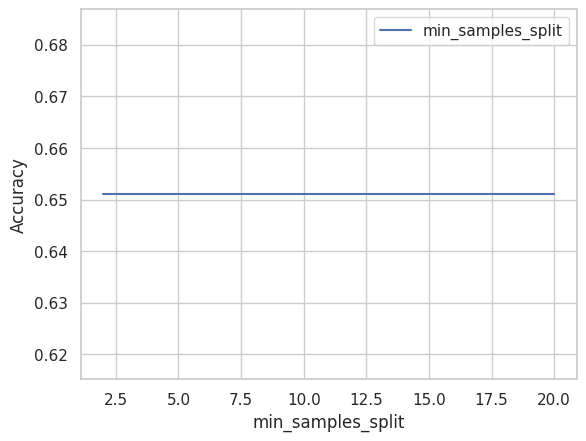

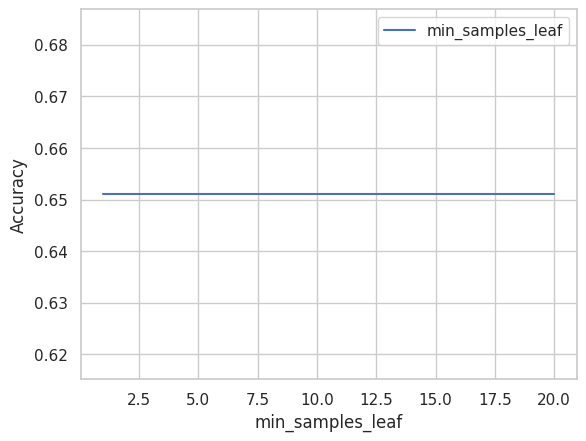

In [44]:
import matplotlib.pyplot as plt

def plot_parameter_effect(param_name, param_values):
    scores = []
    for value in param_values:
        kwargs = {param_name: value}
        tree = DecisionTree(**kwargs)
        tree.fit(X_train, y_train)
        y_pred = tree.predict(X_test)
        scores.append(accuracy_score(y_test, y_pred))
    plt.plot(param_values, scores, label=param_name)
    plt.xlabel(param_name)
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_parameter_effect("max_depth", range(1, 11))

plot_parameter_effect("min_samples_split", range(2, 21))


plot_parameter_effect("min_samples_leaf", range(1, 21))


__Задание 9. (до 3-х баллов)__

Реализуйте класс `LinearRegressionTree`:

 - Если вам удобно, можете сделать его наследуемым от `DecisionTree` и переопределить только необходимые методы. Можете добавить новые — как вам нравится.
 - В листьях находятся не константные предсказания, а линейные модели (можно использовать из библиотеки `sklearn`).
 - Ваша реализация должна решать задачу __регрессии__, поэтому для поиска оптимального разбиения нужно написать новую функцию.
 - **Максимум 1.8 балла, если**:
   - В качестве критерия для разбиения считаете среднее квадратное/абсолютное отклонение
   - Перебираете все пороги
   - Ваша реализация строится как обычное решающее дерево для регрессии, но в листьях линейные модели.
   - Есть поддержка параметра max_depth
 - **Максимум три балла, если выполнено следующее**:
     - Для разбиения перебираются не все пороги. Пороги выбираются из значений признаков, разбитых на квантили.
     - Для разбиении выбирается порог, который минимизирует суммарную ошибку линейных моделей после разбиения: $$\text{loss} = \frac{n_{left}}{n} \cdot \text{loss}_{left} + \frac{n_{right}}{n} \cdot \text{loss}_{right}$$ (Разумеется, для оценки этих ошибок вам надо будет строить много линейных моделей, это не дисперсии. В качестве функционала ошибки возьмите MAE или MSE)
     - Есть поддержка параметров max_depth, min_samples_split, min_samples_leaf

__Задание 10. (1 балл)__

Проведите эксперименты с реализованным вами линейным деревом на любом подходящем датасете из sklearn (https://scikit-learn.org/1.5/datasets/real_world.html), который вам нравится. Подберите лучшие гиперпараметры (max_depth и остальные, если вы их реализовывали). Сравните ваше дерево со стандартным деревом для регрессии из sklearn, для него тоже подберите гиперпараметры.

Посмотрите, что будет, если обучить ваше дерево на данных, которые сгенерированы внизу. Нарисуйте график с предсказаниями и таргетами на всей выборке, сравните с обычным деревом.

Напишите, какие достоинства и недостатки вы видите у реализованного вами линейного дерева.

In [ ]:
n_samples = 3_000
x = np.linspace(0, 5, n_samples).reshape(-1, 1)
y = np.sin(x.flatten()) + np.random.normal(0, 0.1, n_samples) * np.random.normal(0, 1, n_samples)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.95, random_state=0x4b524f4c2d562d53544f594c4f % (2 ** 32 - 1))

# YOUR CODE

**Ответ:**

Вставьте что угодно, описывающее ваши впечатления от этого задания:

In [ ]:
сигма сигма бой сигма бой сигма бой каждая девчонка хочет танцевать с тобой
сигма сигма бой сигма бой сигма бой я такая вся что добиваться будешь год